# Benchmark
Using nBody, benchmark 2 different machines. In this case, the machines are shown in the tables below and both run Windows 10.
Each experiment has 30 independent samples. 

## Preprocessing
NBody has been executed on a single core of the 2 machines and they have reported results in the `amd_3700x.csv` and `amd_3700u.csv` files. In this phase, let's combine the 2 files in a single dataframe. We will use the average value produced by nBody to perform further analysis.

In [1]:
import pandas as pd

fname = "amd_3700u.csv"

df_3700u = pd.read_csv(fname, sep=";", header=None)

headers = [f"Rep-{i+1}" for i in range(len(df_3700u.columns))]

df_3700u.columns = headers
df_3700u.head()

,Rep-1,Rep-2,Rep-3,Rep-4,Rep-5,Rep-6,Rep-7,Rep-8,Rep-9,Rep-10,...,Rep-21,Rep-22,Rep-23,Rep-24,Rep-25,Rep-26,Rep-27,Rep-28,Rep-29,Rep-30
0,695281,650839,647188,663721,650400,681395,661836,656316,659399,653289,...,685543,655366,654189,662907,663201,647130,649592,648464,656166,650137
1,654865,660044,648768,650678,648867,693375,648851,657322,650410,666229,...,681484,666826,652321,681573,674695,647949,650057,649368,647140,654508
2,652031,650034,649799,649265,654524,695266,644903,647669,655484,647538,...,656176,649606,653389,660247,670140,648994,648832,645365,652860,652678
3,647861,647434,645327,649004,657793,690582,648897,647272,653928,645296,...,649903,647937,652172,656815,653121,647734,649429,646388,652950,654616
4,656974,663303,649256,645088,655782,673292,648379,650112,653023,647572,...,648356,647937,649846,655119,651444,648586,648732,645810,652236,652960


In [2]:
import pandas as pd

fname = "amd_3700x.xlsx"

df_3700x = pd.read_excel(fname, header=None, skiprows=[0])

headers = [f"Rep-{i+1}" for i in range(len(df_3700u.columns))]

df_3700x.columns = headers

df_3700x.head()

,Rep-1,Rep-2,Rep-3,Rep-4,Rep-5,Rep-6,Rep-7,Rep-8,Rep-9,Rep-10,...,Rep-21,Rep-22,Rep-23,Rep-24,Rep-25,Rep-26,Rep-27,Rep-28,Rep-29,Rep-30
0,218865.0,214745.0,208684.0,212723.0,209044.0,209054.0,209284.0,208763.0,209911.0,205957.0,...,219531.0,210138.0,209796.0,212197.0,209279.0,209921.0,209500.0,209851.0,210898.0,209196.0
1,209106.0,216271.0,209562.0,214975.0,209635.0,212508.0,210013.0,208756.0,210789.0,211658.0,...,243266.0,210650.0,210196.0,214706.0,209787.0,211173.0,209968.0,211015.0,211190.0,210155.0
2,208554.0,214640.0,212503.0,214074.0,209590.0,220318.0,210266.0,211747.0,208988.0,214024.0,...,237577.0,211943.0,212533.0,214152.0,210665.0,211680.0,210980.0,210937.0,213063.0,208625.0
3,208630.0,219890.0,212674.0,213470.0,210183.0,216718.0,209578.0,208238.0,212447.0,214524.0,...,216371.0,212618.0,215589.0,213914.0,210333.0,212474.0,210096.0,211423.0,211239.0,211649.0
4,209146.0,217628.0,209676.0,214204.0,211079.0,219320.0,210213.0,206257.0,213051.0,214056.0,...,214824.0,209408.0,211227.0,217615.0,210649.0,213655.0,211602.0,211873.0,211570.0,217994.0


In [3]:
import pandas as pd

df: pd.DataFrame = pd.concat([df_3700u.mean(), df_3700x.mean(), df_3700u.mean() - df_3700x.mean()], axis=1) 
df.columns = ["AMD-3700u", "AMD-3700x", "Diff"]

df.head()


,AMD-3700u,AMD-3700x,Diff
Rep-1,664116.70,209818.52,454298.18
Rep-2,665445.80,213193.42,452252.38
Rep-3,662676.40,215760.90,446915.50
Rep-4,663829.22,213954.30,449874.92
Rep-5,667700.58,210735.54,456965.04


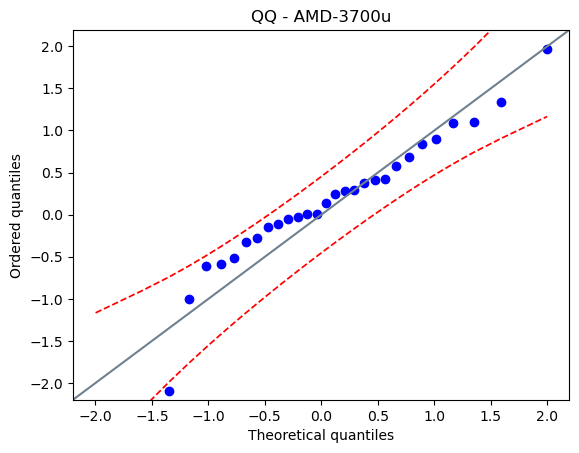

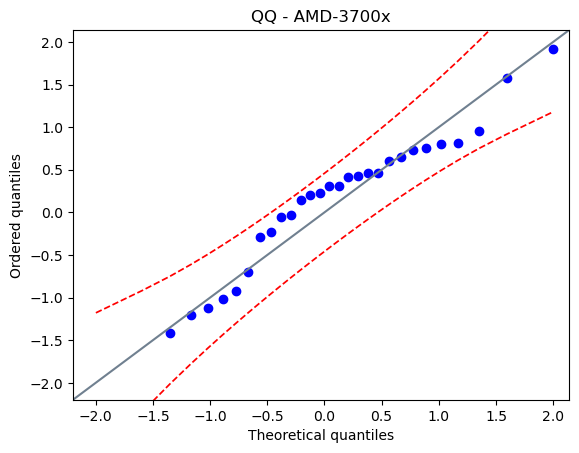

In [4]:
import matplotlib.pyplot as plt
import pingouin as pg
import scipy.stats as st
import numpy as np

# pg.qqplot(df["AMD-3700u"].values, dist="norm")
# plt.title("QQ - AMD-3700u")
# plt.show()

# pg.qqplot(df["AMD-3700x"].values, dist="norm")
# plt.title("QQ - AMD-3700x")
# plt.show()

# https://github.com/raphaelvallat/pingouin/blob/master/pingouin/plotting.py
def qqplot(x: np.ndarray, conf=.95):
    def _ppoints(n, a=0.5):
        a = 3 / 8 if n <= 10 else 0.5
        return (np.arange(n) + 1 - a) / (n + 1 - 2 * a)

    _scatter_kwargs = {"marker": "o", "color": "blue"}

    quantiles = st.probplot(x, dist="norm", fit=False)
    theor, observed = quantiles[0], quantiles[1]

    fit_params = st.norm.fit(x)
    loc = fit_params[-2]
    scale = fit_params[-1]
    shape = fit_params[:-2] if len(fit_params) > 2 else None

    # Observed values to observed quantiles
    if loc != 0 and scale != 1:
        observed = (np.sort(observed) - fit_params[-2]) / fit_params[-1]

    slope, intercept, r, _, _ = st.linregress(theor, observed)

    ax = plt.gca()

    ax.scatter(theor, observed, **_scatter_kwargs)

    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Ordered quantiles")

    # Add diagonal line
    end_pts = [ax.get_xlim(), ax.get_ylim()]
    end_pts[0] = min(end_pts[0])
    end_pts[1] = max(end_pts[1])
    ax.plot(end_pts, end_pts, color="slategrey", lw=1.5)
    ax.set_xlim(end_pts)
    ax.set_ylim(end_pts)

    fit_val = slope * theor + intercept

    # confidence bar
    n = x.size
    P = _ppoints(n)
    crit = st.norm.ppf(1 - (1 - conf) / 2)
    pdf = st.norm.pdf(theor)
    se = (slope / pdf) * np.sqrt(P * (1 - P) / n)
    upper = fit_val + crit * se
    lower = fit_val - crit * se
    ax.plot(theor, upper, "r--", lw=1.25)
    ax.plot(theor, lower, "r--", lw=1.25)

qqplot(df["AMD-3700u"].values)
plt.title("QQ - AMD-3700u")
plt.show()

qqplot(df["AMD-3700x"].values)
plt.title("QQ - AMD-3700x")
plt.show()



## Calculate confidance interval

In [31]:
import scipy.stats as st
import numpy as np

samples = df["Diff"].head(30).values
mean, std, n = np.mean(samples), np.std(samples, ddof=1), len(samples)

alpha = 0.05
q = 1-alpha/2

z = st.t.ppf(q=q, df=n-1) * std / np.sqrt(n-1)

print("z:",z, "lb:", mean - z, "ub:", mean + z, "conf:", (1-alpha)*100, "%", "err:", 2*z)

# same result for confidence interval
se = st.sem(samples, ddof=1)
ci = st.t.interval(1-alpha, n-1, loc=mean, scale=se)

print(ci, "err:", ci[1] - ci[0])

z: 1371.5986222849183 lb: 450619.3387110483 ub: 453362.5359556182 conf: 95.0 % err: 2743.1972445698366
(450642.3924306207, 453339.4822360458) err: 2697.0898054251447
